# 02 — Katman Tutarlılığı (Cross-Validation)

Gerçek WSM sisteminde farklı sekmeler (Satış, UE1T, Günlük) birbirini doğrular.

**Kontrol edilecekler:**
1. UE1T iç mutabakat denklemi
2. Dönem sürekliliği (son → sonraki baş)
3. transactions → ue1t (30 dk toplam)
4. ue1t → daily (günlük toplam)
5. deliveries → daily (dolum)

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.validation import run_all_checks, check_ue1t_balance
from utils.plots import setup_style

setup_style()
dfs = load_all()
checks = run_all_checks(dfs)
checks['summary']

{'mutabakat_max_abs': 3.637978807091713e-12,
 'sureklilik_gt_001': 0,
 'tx_ue1t_gt_001': 2941,
 'daily_satis_max_fark': 7.275957614183426e-12,
 'delivery_fark_gt_001': 4}

Mutabakat residual istatistikleri:
count    1.381940e+05
mean     6.844541e-16
std      7.481341e-13
min     -3.637979e-12
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.637979e-12
Name: mutabakat_residual, dtype: float64
Max abs: 3.637978807091713e-12


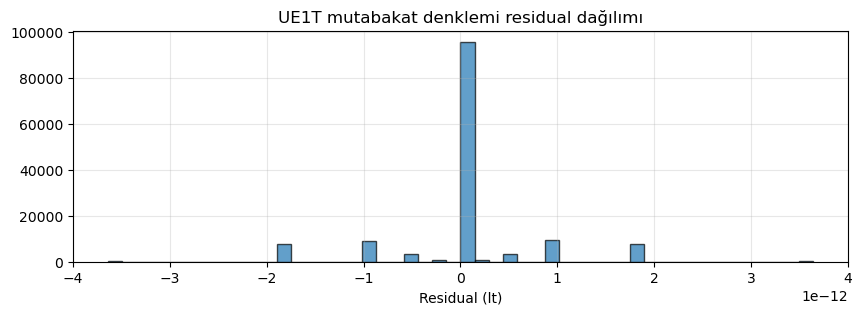

In [2]:
# 1) UE1T mutabakat denklemi
ue1t_bal = checks['ue1t_balance']
print('Mutabakat residual istatistikleri:')
print(ue1t_bal['mutabakat_residual'].describe())
print('Max abs:', ue1t_bal['mutabakat_residual'].abs().max())

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(ue1t_bal['mutabakat_residual'], bins=50, edgecolor='k', alpha=0.7)
ax.set_xlabel('Residual (lt)')
ax.set_title('UE1T mutabakat denklemi residual dağılımı')
plt.show()

In [3]:
# 2) Süreklilik — kesinti dışı beklenen ~0
cont = checks['continuity']
big = cont[cont['sureklilik_fark'].abs() > 0.01]
print(f'Süreklilik |fark|>0.01 satır: {len(big)} (kesinti/boşluk normal)')
if len(big):
    display(big[['istasyon_kodu','tank_no','saat_1','onceki_son','donem_basi_stok','sureklilik_fark']].head(10))

Süreklilik |fark|>0.01 satır: 0 (kesinti/boşluk normal)


TX vs UE1T uyuşmayan dönem: 2941
Unmapped satış litre toplamı: 93008.1


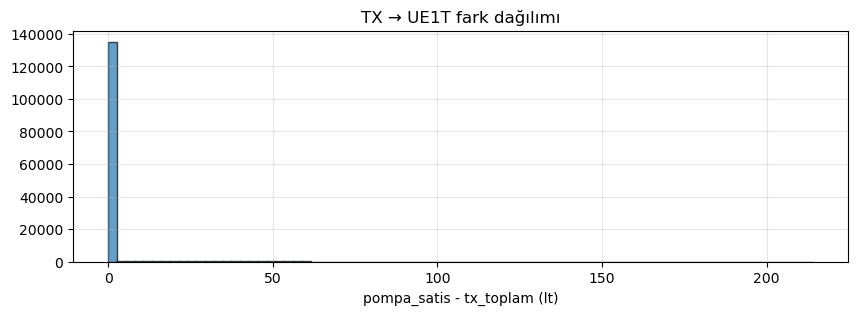

In [4]:
# 3) TX → UE1T
txu = checks['tx_to_ue1t']
mismatch = txu[txu['tx_ue1t_fark'].abs() > 0.01]
print(f'TX vs UE1T uyuşmayan dönem: {len(mismatch)}')
print(f'Unmapped satış litre toplamı: {dfs["transactions"].loc[dfs["transactions"].tank_no.isna(), "litre"].sum():.1f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(txu['tx_ue1t_fark'], bins=80, edgecolor='k', alpha=0.7)
ax.set_xlabel('pompa_satis - tx_toplam (lt)')
ax.set_title('TX → UE1T fark dağılımı')
plt.show()

In [5]:
# 4) UE1T → Daily
ud = checks['ue1t_to_daily']
for col in ['satis_fark','dolum_fark','acilis_fark','kapanis_fark']:
    print(f'{col}: max abs = {ud[col].abs().max():.6f}')

alarm_gun = ud[ud['satis_fark'].abs() > 0.01]
if len(alarm_gun):
    display(alarm_gun.head())

satis_fark: max abs = 0.000000
dolum_fark: max abs = 0.000000
acilis_fark: max abs = 0.000000
kapanis_fark: max abs = 0.000000


In [6]:
# 5) Deliveries → Daily
dd = checks['deliveries_to_daily']
bad = dd[dd['delivery_fark'].abs() > 0.01]
print(f'Delivery vs daily fark >0.01 gün: {len(bad)}')
print('(Gün sonu dolum kayması olabilir — EDA bulgusu)')
if len(bad):
    display(bad[['tarih','istasyon_kodu','tank_no','dolum','dolum_net','delivery_fark']].head(10))

Delivery vs daily fark >0.01 gün: 4
(Gün sonu dolum kayması olabilir — EDA bulgusu)


,tarih,istasyon_kodu,tank_no,dolum,dolum_net,delivery_fark
2444,2026-01-15,IST_007,3,0.00,4325.05,-4325.05
2445,2026-01-16,IST_007,3,4325.05,0.00,4325.05
2534,2026-01-15,IST_007,4,0.00,4532.83,-4532.83
2535,2026-01-16,IST_007,4,4532.83,0.00,4532.83


In [7]:
# Tek tank, tek gün derin doğrulama
IST, TANK, GUN = 'IST_001', 1, pd.Timestamp('2026-01-01')
u = dfs['ue1t_30min'][(dfs['ue1t_30min'].istasyon_kodu==IST)&(dfs['ue1t_30min'].tank_no==TANK)]
u = u[u.saat_1.dt.normalize()==GUN]
t = dfs['transactions'][(dfs['transactions'].istasyon_kodu==IST)&(dfs['transactions'].tank_no==TANK)]
t = t[t.satis_zamani.dt.normalize()==GUN]
d = dfs['daily'][(dfs['daily'].istasyon_kodu==IST)&(dfs['daily'].tank_no==TANK)&(dfs['daily'].tarih==GUN)]

print('=== IST_001 Tank 1 — 2026-01-01 ===')
print(f'daily.satis      = {d.satis.iloc[0]:.2f}')
print(f'ue1t toplam      = {u.pompa_satis.sum():.2f}')
print(f'tx toplam        = {t.litre.sum():.2f}')
print(f'daily.acilis     = {d.acilis.iloc[0]:.2f}  | ue1t ilk = {u.donem_basi_stok.iloc[0]:.2f}')
print(f'daily.kapanis    = {d.kapanis.iloc[0]:.2f}  | ue1t son = {u.donem_sonu_stok.iloc[-1]:.2f}')

=== IST_001 Tank 1 — 2026-01-01 ===
daily.satis      = 4069.95
ue1t toplam      = 4069.95
tx toplam        = 4069.95
daily.acilis     = 16846.98  | ue1t ilk = 16846.98
daily.kapanis    = 12779.79  | ue1t son = 12779.79


## Sonuç

Katmanlar tutarlı. TX↔UE1T farkları çoğunlukla **unmapped satış** (`tank_no` null) kaynaklı.

Sonraki: null analizi (`03_null_ve_eksik_veri.ipynb`).